In [1]:
import gwosc
import matplotlib.pyplot as plt
import torch
import matplotlib.pyplot as plt
import numpy as np
import plotfancy as pf
from scipy.signal.windows import tukey
import jax
import jax.numpy as jnp

import matplotlib.pyplot as plt
from gwpy.timeseries import TimeSeries
from gwosc.datasets import event_gps

pf.housestyle_rcparams()

True

In [65]:
defaults = {
    "approximant": "IMRPhenomD",
    "f_min": 20., #40.0,
    "f_max": 1024., #400.0,
    "f_ref": 20.0,
    "notches": [60.0, 120.0, 180.0],
    "notch_width": 0.1,
    "trigger_time": 1126259462.4,
    "pre_trigger_time": 2.0,
    "post_trigger_time": 2.0,
    "data_window": 1000,
    "psd_window":4,
    # "psd_pad": 16.0,
    "ifo": "H1",
    # "tukey_alpha": 0.2,
    "posterior_samples_path": "GW150814_posterior_samples.npz",
}

class Base_GW1501914:
    def __init__(self, settings:dict={}):
        self.settings = settings
        self._unpack_settings()
        self._initialise_gw()
    
    def _unpack_settings(self):
        self.approximant = self.settings.get("approximant", "IMRPhenomD")
        self.f_min = self.settings.get("f_min", 20.)
        self.f_max = self.settings.get("f_max", 1024.)
        self.f_ref = self.settings.get("f_ref", 20.0)
        self.notches = self.settings.get("notches", [60.0, 120.0, 180.0])
        self.notch_width = self.settings.get("notch_width", 0.1)
        self.trigger_time = self.settings.get("trigger_time", 1126259462.4)
        self.pre_trigger_time = self.settings.get("pre_trigger_time", 2.0)
        self.post_trigger_time = self.settings.get("post_trigger_time", 2.0)
        self.data_window = self.settings.get("data_window", 1000)
        self.psd_window = self.settings.get("psd_window", 4)
        # self.psd_pad = self.settings.get("psd_pad", 16.0)
        self.ifo = self.settings.get("ifo", "H1")
        # self.tukey_alpha = self.settings.get("tukey_alpha", 0.2) #### CHANGE THIS ####
        self.posterior_samples_path = self.settings.get(
            "posterior_samples_path", "../../mist-base/GW/GW150814_posterior_samples.npz"
        )
        self.key = jax.random.PRNGKey(42)

    def _initialise_gw(self):
        self.event_time = event_gps('GW150914')
        print(f'Fetching {self.data_window}s of data from {self.ifo}. Will take <4mins.')
        self.gwosc_data = TimeSeries.fetch_open_data(self.ifo, self.event_time-self.data_window/2, 
                                                     self.event_time+self.data_window/2, sample_rate=4096)
        print(f'Calculating PSD for FFT window length {self.psd_window}s.')
        self.psd = self.gwosc_data.psd(fftlength=self.psd_window)
        self.frequencies = self.psd.frequencies
        self.tukey_alpha = 0.5/self.psd_window
        
    def _tukey(self, x):
        # x is supplied in form [nsamples,nbins]
        x = np.array(x)
        window = tukey(np.shape(x)[1], alpha=self.tukey_alpha) # shape [nbins]
        return x*np.expand_dims(window,axis=0) # shape [nsamples, nbins]

    def _get_noise_td(self, nsamples):
        nbins = len(self.gwosc_data.crop(self.event_time-self.psd_window/2, self.event_time+self.psd_window/2))
        alldata_raw = jnp.array(self.gwosc_data)
        max_start_index = alldata_raw.shape[0] - nbins
        start_indices = jax.random.randint(self.key, shape=(nsamples,), minval=0, maxval=max_start_index + 1)
        offsets = jnp.arange(nbins)
        indices = start_indices[:, None] + offsets
        return alldata_raw[indices]
    
    def _get_noise_fd(self, nsamples):
        noise_td = self._get_noise_td(nsamples=nsamples)
        noise_td_windowed = self._tukey(noise_td)
        noise_fd_complex = jnp.fft.rfft(noise_td_windowed)*self.gwosc_data.dt
        prefactor = np.expand_dims(np.sqrt(np.array(self.psd.data)), axis=0)
        return jnp.abs(noise_fd_complex/prefactor)




In [66]:
gw = Base_GW1501914()

Fetching 1000s of data from H1. Will take <4mins.
Calculating PSD for FFT window length 4s.


In [67]:
noise_td = gw._get_noise_td(nsamples=85)
noise_td_windowed = gw._tukey(noise_td)
noise_fd_complex = jnp.fft.rfft(noise_td_windowed)
prefactor = jnp.expand_dims(jnp.sqrt(jnp.array(gw.psd.data)), axis=0)

(0.0, 900.0)

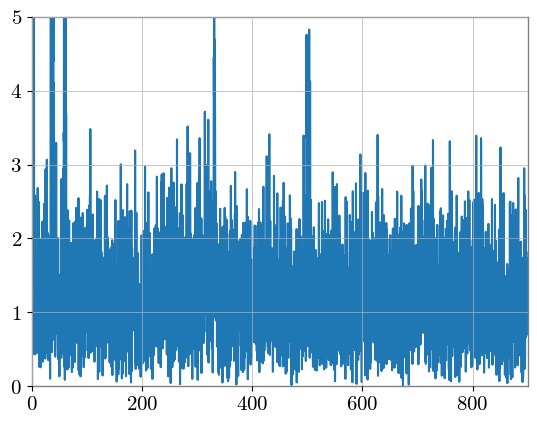

In [68]:
noise_fd = gw._get_noise_fd(85)
one = noise_fd[43]
plt.plot(gw.frequencies,one)
plt.ylim([0,5])
plt.xlim([0,900])

In [55]:
one.shape

(8193,)